## MIT, Lab 5
### Soumik Bhattacharyya, MDE2026005

In [3]:
# imports

import numpy as np

In [10]:
### Basic matrix operations

def matrix_transpose(matrix):
    matrix_transpose = np.zeros((matrix.shape[1], matrix.shape[0]))

    for i in range(matrix_transpose.shape[0]):
        for j in range(matrix_transpose.shape[1]):
            matrix_transpose[i, j] = matrix[j, i]

    return matrix_transpose


def matrix_product(matrix_1, matrix_2):
    if matrix_1.shape[1] != matrix_2.shape[0]:
        print("Shape mismatch.")
        return 0

    matrix_12 = np.zeros((matrix_1.shape[0], matrix_2.shape[1]))

    for i in range(matrix_12.shape[0]):
        for j in range(matrix_12.shape[1]):
            for k in range(matrix_1.shape[1]):
                matrix_12[i, j] += (matrix_1[i, k] * matrix_2[k, j])

    return matrix_12


def vector_dot_product(vector_1, vector_2):
    return matrix_product(matrix_transpose(vector_1), vector_2)[0, 0]


def vector_norm(vector_1):
    return vector_dot_product(vector_1, vector_1) ** 0.5


## Ax = b

def matrix_rank(matrix):
    A = matrix.astype(float).copy()

    rows = A.shape[0]
    cols = A.shape[1]

    rank = 0
    row = 0

    for col in range(cols):
        pivot_row = row

        for i in range(row + 1, rows):
            if abs(A[i, col]) > abs(A[pivot_row, col]):
                pivot_row = i

        if abs(A[pivot_row, col]) < 1e-10:
            continue

        if pivot_row != row:
            temp = A[row].copy()
            A[row] = A[pivot_row]
            A[pivot_row] = temp

        for i in range(row + 1, rows):
            if abs(A[i, col]) > 1e-10:
                factor = A[i, col] / A[row, col]
                for j in range(col, cols):
                    A[i, j] = A[i, j] - factor * A[row, j]

        rank += 1
        row += 1

        if row == rows:
            break

    return rank


def gauss_jordan(matrix_A, vector_b):
    n = matrix_A.shape[0]

    aug_matrix = np.concatenate([matrix_A, vector_b], axis=1).astype(float)

    for col in range(n):
        pivot = col

        for row in range(col + 1, n):
            if abs(aug_matrix[row, col]) > abs(aug_matrix[pivot, col]):
                pivot = row

        if abs(aug_matrix[pivot, col]) < 1e-10:
            return None

        aug_matrix[[col, pivot]] = aug_matrix[[pivot, col]]

        aug_matrix[col] = aug_matrix[col] / aug_matrix[col, col]

        for row in range(n):
            if row != col:
                factor = aug_matrix[row, col]
                aug_matrix[row] = aug_matrix[row] - factor * aug_matrix[col]

    return aug_matrix[:, n].reshape(n, 1)



def solve_linear_system(matrix_A, vector_b):
    if matrix_A.shape[0] != matrix_A.shape[1]:
        print("Please enter a square matrix for the coefficient matrix.")
        return None

    if matrix_A.shape[0] != vector_b.shape[0]:
        print("Mismatch between number of entries in LHS and RHS.")
        return None

    aug_matrix_Ab = np.concatenate([matrix_A, vector_b], axis=1)

    n = matrix_A.shape[0]

    rank_A = matrix_rank(matrix_A)
    rank_Ab = matrix_rank(aug_matrix_Ab)

    if rank_A == rank_Ab == n:
        solution = gauss_jordan(matrix_A, vector_b)
        return solution

    elif rank_A == rank_Ab < n:
        print("Infinitely many solutions exist for given A and b.")
        return None

    elif rank_A < rank_Ab:
        print("No solution exists for given A and b.")
        return None

    else:
        print("Input is not valid.")
        return None



# Orthogonal projection

def orthogonal_projection(A, b):

    # A^T
    AT = matrix_transpose(A)

    # A^T A
    ATA = matrix_product(AT, A)

    # A^T b
    ATb = matrix_product(AT, b)

    # Solve:
    # (A^T A)x = A^T b
    coefficients = solve_linear_system(ATA, ATb)

    # Projection = A c
    projection = matrix_product(A, coefficients)

    return projection


def gram_schmidt(vectors):

    orthonormal = []

    for v in vectors:

        # Make a copy; v is an n x 1 column vector
        u = v.copy()

        # Remove components in directions of previous
        # orthonormal vectors
        for q in orthonormal:

            coefficient = vector_dot_product(v, q)

            projection = coefficient * q

            u = u - projection

        # Normalize
        norm = vector_norm(u)

        if norm > 1e-12:
            q = (1 / norm) * u
            orthonormal.append(q)

    return orthonormal

def perp_component(A, b):

    projection = orthogonal_projection(A, b)

    difference = b - projection

    return difference


# SVD

def svd_from_matrix(matrix):

    # A^T
    transpose = matrix_transpose(matrix)

    # A^T A
    ata = matrix_product(transpose, matrix)

    # Eigenvalues and eigenvectors of A^T A
    eigenvalues, eigenvectors = np.linalg.eigh(ata)

    # Sort eigenvalues in descending order
    order = np.argsort(eigenvalues)[::-1]

    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    # Remove very small negative values caused by numerical error
    eigenvalues[eigenvalues < 0] = 0

    # Number of singular values
    number = min(matrix.shape[0], matrix.shape[1])

    # Singular values
    singular_values = np.sqrt(
        eigenvalues[:number]
    )

    # V
    V = eigenvectors[:, :number]

    # Sigma
    sigma = np.zeros(
        (number, number)
    )

    for i in range(number):
        sigma[i, i] = singular_values[i]

    # U = A V / sigma
    U = np.zeros(
        (matrix.shape[0], number)
    )

    for i in range(number):

        if singular_values[i] > 1e-10:

            v = V[:, i].reshape(-1, 1)

            Av = matrix_product(
                matrix,
                v
            )

            U[:, i] = (
                Av.flatten()
                / singular_values[i]
            )

    return U, sigma, V



In [13]:
A = np.array([[4], [2], [0]])
B = np.array([[1], [2], [2]])

proj_B_A = orthogonal_projection(B, A)

print("proj(b) a=")
print(proj_B_A)
print("\n")

print("The perpendicular component:")
perp_comp = perp_component(B, A)
print(perp_comp)

proj(b) a=
[[0.88888889]
 [1.77777778]
 [1.77777778]]


The perpendicular component:
[[ 3.11111111]
 [ 0.22222222]
 [-1.77777778]]


In [14]:
v1 = np.array([[1], [0], [1]])
v2 = np.array([[0], [1], [1]])

vector_x = np.array([[2], [3], [4]])

ortho_norm = gram_schmidt([v1, v2])

print("The orthonormal vector with Gram-Schmidt is:")
print(ortho_norm)
print("\n")


matrix_Q = np.hstack((ortho_norm[0], ortho_norm[1]))
projection_matrix_P = matrix_product(matrix_Q, matrix_transpose(matrix_Q))

print("Projection matrix P:")
print(projection_matrix_P)
print("\n")


projection_Px = matrix_product(projection_matrix_P, vector_x)

print("Projection (Px):")
print(projection_Px)

The orthonormal vector with Gram-Schmidt is:
[array([[0.70710678],
       [0.        ],
       [0.70710678]]), array([[-0.40824829],
       [ 0.81649658],
       [ 0.40824829]])]


Projection matrix P:
[[ 0.66666667 -0.33333333  0.33333333]
 [-0.33333333  0.66666667  0.33333333]
 [ 0.33333333  0.33333333  0.66666667]]


Projection (Px):
[[1.66666667]
 [2.66666667]
 [4.33333333]]


(740, 493)


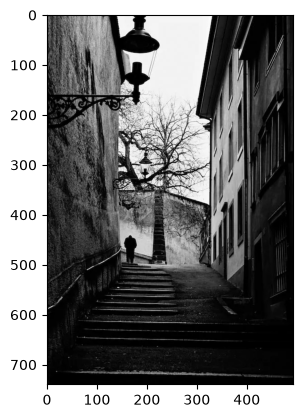

In [17]:
import cv2
import matplotlib.pyplot as plt

# from google.colab.patches import cv2_imshow

# Load image in grayscale
image = cv2.imread("grayscale_staircase.png", cv2.IMREAD_GRAYSCALE)

print(image.shape)

plt.imshow(image, cmap='gray')
plt.show()


In [18]:
# image_svd = svd_from_matrix(image)

In [19]:
U, d, Vt = np.linalg.svd(image)

print(U.shape)
print(d.shape)
print(Vt.shape)


(740, 740)
(493,)
(493, 493)


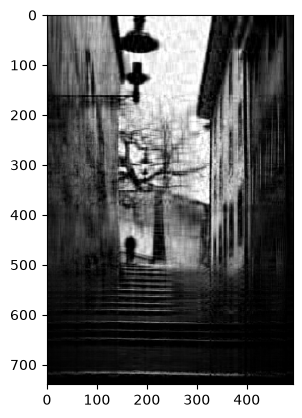

In [20]:
reconstructed_image_k20 = U[:, :20] @ np.diag(d[:20]) @ Vt[:20, :]

reconstructed_image_k20 = np.clip(reconstructed_image_k20, 0, 255).astype(np.uint8)

plt.imshow(reconstructed_image_k20, cmap='gray')
plt.show()

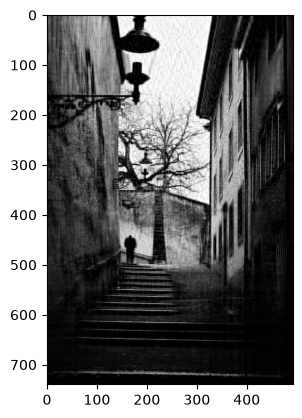

In [21]:
reconstructed_image_k50 = U[:, :50] @ np.diag(d[:50]) @ Vt[:50, :]

reconstructed_image_k50 = np.clip(reconstructed_image_k50, 0, 255).astype(np.uint8)

plt.imshow(reconstructed_image_k50, cmap='gray')
plt.show()

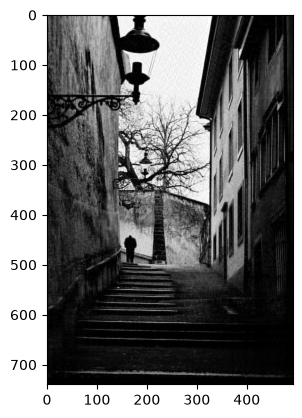

In [22]:
reconstructed_image_k100 = U[:, :100] @ np.diag(d[:100]) @ Vt[:100, :]

reconstructed_image_k100 = np.clip(reconstructed_image_k100, 0, 255).astype(np.uint8)

plt.imshow(reconstructed_image_k100, cmap='gray')
plt.show()

### Comments

